In [1]:
import pandas as pd
import glob
import os

# Input folder
data_folder = 'Data/'
csv_files = glob.glob(os.path.join(data_folder, 'Participant_*.csv'))

# Define body locations and acceleration axes
body_locations = ['Left_pocket', 'Right_pocket', 'Wrist', 'Upper_arm', 'Belt']
accel_axes = ['Ax', 'Ay', 'Az']

# List to hold all cleaned DataFrames
all_data = []

for file_path in csv_files:
    with open(file_path, 'r') as f:
        line1 = f.readline().strip().split(',')
        line2 = f.readline().strip().split(',')

    # Combine the two header rows
    header = []
    current_prefix = None
    for part1, part2 in zip(line1, line2):
        if part1:
            current_prefix = part1.strip()
        if part2:
            header.append(f"{current_prefix}_{part2.strip()}")
        else:
            header.append("")

    # Read actual data
    df = pd.read_csv(file_path, skiprows=2, header=None)
    df.columns = header

    # Extract participant ID from filename
    participant_id = int(os.path.basename(file_path).split('_')[1].split('.')[0])

    # Get activity from column index 69 (only once — it's global per row)
    if df.shape[1] > 69:
        activity_col = df.iloc[:, 69].values
    else:
        activity_col = ['unknown'] * len(df)

    # Process each position
    for loc in body_locations:
        cols = [f"{loc}_{axis}" for axis in accel_axes if f"{loc}_{axis}" in df.columns]

        if not cols:
            continue

        temp_df = df[cols].copy()
        temp_df.columns = accel_axes
        temp_df['position'] = loc
        temp_df['participant'] = participant_id
        temp_df['activity'] = activity_col

        all_data.append(temp_df)

# Combine everything
combined_df = pd.concat(all_data, ignore_index=True)

# Save
combined_df.to_csv('combined_accel_with_activity.csv', index=False)

# Print summary
print(combined_df.sample(5))
print(f"\n Total rows combined: {combined_df.shape[0]}")
print(f" Output saved as: combined_accel_with_activity.csv")




             Ax       Ay      Az     position  participant    activity
2418884 -4.7263 -10.4200 -8.8941    Upper_arm            7     jogging
1126952  3.4459  -8.6898 -2.6696        Wrist            3  downstairs
1313149  3.2553  -4.9442 -2.1520  Left_pocket            4    upstairs
1799988  2.0022  -8.9077 -2.6560    Upper_arm            5     sitting
860222   2.9420  -8.0088 -3.8409    Upper_arm            2      biking

 Total rows combined: 3150000
 Output saved as: combined_accel_with_activity.csv


In [2]:
# Reading the combined data
# Load the preprocessed data
combined_df = pd.read_csv('Data/combined_accel_with_activity.csv')
combined_df.head()

,time_stamp,Ax,Ay,Az,position,participant,activity
0,1.390000e+12,-1.81150,-14.873,-1.34840,Left_pocket,1,walking
1,1.390000e+12,0.24517,-14.070,-0.84446,Left_pocket,1,walking
2,1.390000e+12,-0.57205,-14.628,-1.75700,Left_pocket,1,walking
3,1.390000e+12,-0.69464,-12.939,-3.09180,Left_pocket,1,walking
4,1.390000e+12,0.87170,-12.000,-1.56630,Left_pocket,1,walking


In [3]:
all_df_axis = combined_df[['time_stamp','Ax','Ay','Az','participant','position', 'activity']].copy()
# Convert to numpy array
all_df_axis['activity'].unique()

array(['walking', 'standing', 'jogging', 'sitting', 'biking', 'upstairs',
       'downstairs', 'upsatirs'], dtype=object)

In [4]:
all_df_axis.loc[all_df_axis['activity'] == 'upsatirs', 'activity'] = 'upstairs'
all_df_axis.sample(5)

,time_stamp,Ax,Ay,Az,participant,position,activity
2660698,1.390000e+12,2.2882,-9.24820,-2.24740,8,Wrist,standing
443780,1.390000e+12,3.1191,-9.28910,-0.61292,10,Wrist,walking
2683164,1.390000e+12,6.1155,-2.86030,-7.85890,8,Wrist,biking
2475134,1.390000e+12,16.5080,2.28820,1.77060,7,Belt,jogging
3118605,1.390000e+12,7.3277,-0.23155,-6.36070,9,Belt,sitting


In [5]:
cols_to_numeric = ['Ax', 'Ay', 'Az', 'time_stamp']
for col in cols_to_numeric:
    all_df_axis[col] = pd.to_numeric(all_df_axis[col], errors='coerce')
all_df_axis['participant'] = all_df_axis['participant'].astype('category')
all_df_axis['activity'] = all_df_axis['activity'].astype('category')

In [6]:
all_df_axis.describe()

,time_stamp,Ax,Ay,Az
count,3.150000e+06,3.150000e+06,3.150000e+06,3.150000e+06
mean,1.390000e+12,2.970175e+00,-6.286800e+00,-2.207186e+00
std,0.000000e+00,5.318678e+00,5.467467e+00,3.765335e+00
min,1.390000e+12,-1.960000e+01,-1.966800e+01,-1.949100e+01
25%,1.390000e+12,-8.172200e-02,-9.752200e+00,-4.413000e+00
50%,1.390000e+12,2.506100e+00,-7.150700e+00,-1.661700e+00
75%,1.390000e+12,6.360700e+00,-1.757000e+00,1.089600e-01
max,1.390000e+12,1.960000e+01,1.925900e+01,1.960000e+01


In [7]:
data = all_df_axis.copy()
data

,time_stamp,Ax,Ay,Az,participant,position,activity
0,1.390000e+12,-1.81150,-14.8730,-1.34840,1,Left_pocket,walking
1,1.390000e+12,0.24517,-14.0700,-0.84446,1,Left_pocket,walking
2,1.390000e+12,-0.57205,-14.6280,-1.75700,1,Left_pocket,walking
3,1.390000e+12,-0.69464,-12.9390,-3.09180,1,Left_pocket,walking
4,1.390000e+12,0.87170,-12.0000,-1.56630,1,Left_pocket,walking
...,...,...,...,...,...,...,...
3149995,1.390000e+12,9.05750,-1.9477,-1.28030,9,Belt,downstairs
3149996,1.390000e+12,9.16650,-2.1793,-1.29390,9,Belt,downstairs
3149997,1.390000e+12,10.03800,-3.2144,-1.51190,9,Belt,downstairs
3149998,1.390000e+12,9.62960,-4.2223,-1.70250,9,Belt,downstairs


In [8]:
for i in range(1, len(data['participant'].unique())+1):
    print(f'Participant {i} has {len(data[data["participant"] == i])} rows')

Participant 1 has 315000 rows
Participant 2 has 315000 rows
Participant 3 has 315000 rows
Participant 4 has 315000 rows
Participant 5 has 315000 rows
Participant 6 has 315000 rows
Participant 7 has 315000 rows
Participant 8 has 315000 rows
Participant 9 has 315000 rows
Participant 10 has 315000 rows


In [9]:
import numpy as np
data['accel_magnitude'] = np.sqrt(data['Ax']**2 + data['Ay']**2 + data['Az']**2)

In [10]:
# Check for missing values
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [11]:
import numpy as np

def replace_sensor_errors(data, threshold=1000):
    data = np.array(data, dtype=float)
    n = data.shape[0]

    # Find indices where data > threshold
    error_idx = np.where(data > threshold)[0] # to get the actual indices array from the tuple returned by np.where.

    # Handle the first element if it's an error
    if 0 in error_idx:
        valid_idx = np.where(data <= threshold)[0]
        if valid_idx.size == 0:
            raise ValueError("All values in this dataset are errors")
        data[0] = data[valid_idx[0]]

    # For the rest, replace with previous valid value
    for i in error_idx:
        if i == 0:
            continue
        data[i] = data[i-1]

    return data

# Apply only to the accel_magnitude column
data['accel_magnitude'] = replace_sensor_errors(data['accel_magnitude'].values)

In [12]:
# raw data before feature extraction and window building
data['accel_magnitude'].groupby(data['activity']).describe() 


C:\Users\garog\AppData\Local\Temp\ipykernel_34044\1947727602.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data['accel_magnitude'].groupby(data['activity']).describe()


,count,mean,std,min,25%,50%,75%,max
activity,,,,,,,,
biking,450000.0,10.039184,1.927517,0.921665,9.044184,10.000935,10.950975,30.916655
downstairs,450000.0,10.405523,4.081392,0.268638,7.641863,9.671814,12.538612,31.968675
jogging,450000.0,13.050862,6.521729,0.117166,7.620760,11.966447,19.041573,33.044148
sitting,450000.0,9.756681,0.226904,4.221222,9.652546,9.801582,9.898556,20.934715
standing,450000.0,9.871296,0.283710,3.870511,9.781635,9.890596,9.991227,18.484682
upstairs,450000.0,10.373926,3.151055,0.333906,8.327612,10.048675,12.252458,29.597370
walking,450000.0,10.676270,3.528240,0.288931,8.320685,10.398329,12.661786,31.462008


In [13]:
combined_df.sample(5) # with the other metrics
data.columns
# Group Column is like a time window of 1 second,
# we will leave it out, because we will use a sliding window of 20 seconds.


Index(['time_stamp', 'Ax', 'Ay', 'Az', 'participant', 'position', 'activity',
       'accel_magnitude'],
      dtype='object')

In [14]:
# Keep the essential columns
data_needed = data[['time_stamp','participant','activity','position','accel_magnitude']].copy()

In [15]:
# Save the cleaned and processed data to a new CSV file
output_file_path = 'Data/preprocessed_all_data.csv'
data_needed.to_csv(output_file_path, index=False)

## Creating Time Window
Info:

- window size: 20 sec
- sliding step : 1 sec = 50 Hz
- overlapping windows
- size: 1000samples = 20 seconds * 50 Hz  
- every participant has 63000 samples
- each window does

In [16]:
window_size = 1000   # 20 seconds * 50 Hz
step_size = 50       # 1 second * 50 Hz

participant_1_data = data[data['participant'] == 1].reset_index(drop=True)
windows = []

for start in range(0, len(participant_1_data) - window_size + 1, step_size):
    end = start + window_size
    window = participant_1_data.iloc[start:end]
    windows.append(window)

print(f"Total windows for participant 1: {len(windows)}")

Total windows for participant 1: 6281


# Feature Extraction
for all positions

#### Creating Time Window
Info:

- window size: 20 sec
- sliding step : 1 sec = 50 Hz
- overlapping windows
- size: 1000samples = 20 seconds * 50 Hz  
- every participant has 63000 samples
- each window does

In [17]:
import numpy as np
import pandas as pd

# Load the preprocessed data
data = pd.read_csv('Data/preprocessed_all_data.csv')
data.head()


,time_stamp,participant,activity,position,accel_magnitude
0,1.390000e+12,1,walking,Left_pocket,15.043465
1,1.390000e+12,1,walking,Left_pocket,14.097451
2,1.390000e+12,1,walking,Left_pocket,14.744242
3,1.390000e+12,1,walking,Left_pocket,13.321392
4,1.390000e+12,1,walking,Left_pocket,12.133143


### Overlapping windows with 1-second steps and 20-second window length


In [18]:
# Define window size and step size
window_size = 1000   # 20 seconds * 50 Hz
step_size = 50       # 1 second * 50 Hz

# Initialize a list to hold the windows and their corresponding majority activities
windows = []
activities = []

# Create sliding windows
for start in range(0, len(data) - window_size + 1, step_size):
    end = start + window_size
    window = data.iloc[start:end]
    windows.append(window)
    majority_activity = window['activity'].mode()[0]  # Get the majority activity
    activities.append(majority_activity)

print(f'Total windows created: {len(windows)}')

Total windows created: 62981


In [19]:
# Convert the list of windows and activities into a DataFrame
windowed_data = pd.DataFrame({'window': windows, 'majority_activity': activities})

# Display the first few entries of the windowed data
windowed_data.sample(5)

,window,majority_activity
10199,time_stamp participant activity p...,walking
11539,time_stamp participant activity po...,standing
58688,time_stamp participant activity ...,biking
35648,time_stamp participant activity ...,jogging
4334,time_stamp participant activity p...,sitting


In [20]:
from scipy.stats import skew
from scipy.signal import welch

def extract_features(window, fs=50):
    x = window['accel_magnitude'].values.astype(float)
    features = {}
    features['mean'] = np.mean(x)
    features['std'] = np.std(x)
    features['skewness'] = skew(x)
    features['max'] = np.max(x)
    features['min'] = np.min(x)
    features['range'] = np.max(x) - np.min(x)
    # Welch's method for power spectral density
    f, Pxx = welch(x, fs=fs)
    #https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.welch.html
    
    # Μπορείς να κρατήσεις όλο το φάσμα ή π.χ. το άθροισμα ή το μέγιστο
    features['psd_sum'] = np.sum(Pxx)
    features['psd_max'] = np.max(Pxx)
    # Αν θέλεις όλο το φάσμα:
    # for i, val in enumerate(Pxx):
    #     features[f'psd_{i}'] = val
    return features

# Εξαγωγή χαρακτηριστικών για όλα τα παράθυρα
feature_list = []
for window in windows:
    feats = extract_features(window)
    feature_list.append(feats)

features_df = pd.DataFrame(feature_list)
features_df['majority_activity'] = activities
features_df.sample(5)

,mean,std,skewness,max,min,range,psd_sum,psd_max,majority_activity
3997,9.455486,0.110002,-0.874339,10.236062,8.665376,1.570687,0.074764,0.005831,standing
10248,9.548300,1.732702,0.512156,15.180790,5.674828,9.505963,17.789467,8.196212,walking
5940,10.269337,3.391907,0.190604,21.271298,0.706952,20.564346,71.390263,9.849303,upstairs
22784,9.659133,1.762816,-0.043990,13.913276,6.093173,7.820102,15.766965,5.849313,walking
44532,15.730413,5.146064,-0.016459,27.409266,1.090945,26.318321,134.154551,29.902099,jogging


In [21]:
from scipy.stats import skew
from scipy.signal import welch

def extract_features(window, fs=50):
    x = window['accel_magnitude'].values.astype(float)
    features = {}
    features['mean'] = np.mean(x)
    features['std'] = np.std(x)
    features['skewness'] = skew(x)
    features['max'] = np.max(x)
    features['min'] = np.min(x)
    features['range'] = np.max(x) - np.min(x)
    f, Pxx = welch(x, fs=fs)
    features['psd_sum'] = np.sum(Pxx)
    features['psd_max'] = np.max(Pxx)
    return features

# Helper to extract features for a given position
def extract_features_for_position(windows, activities, position_name):
    feature_list = []
    majority_activities = []
    participants = []
    positions = []
    for window, activity in zip(windows, activities):
        if window['position'].iloc[0] == position_name:
            feats = extract_features(window)
            feature_list.append(feats)
            majority_activities.append(activity)
            participants.append(window['participant'].iloc[0])
            positions.append(position_name)
    features_df = pd.DataFrame(feature_list)
    features_df['majority_activity'] = majority_activities
    features_df['participant'] = participants
    features_df['position'] = positions
    return features_df

# Create features_df for Left_pocket
features_left = extract_features_for_position(windows, activities, 'Left_pocket')
print("Left_pocket features:")
print(features_left.sample(5))

# Create features_df for Right_pocket
features_right = extract_features_for_position(windows, activities, 'Right_pocket')
print("Right_pocket features:")
print(features_right.sample(5))

# Create features_df for Wrist
features_wrist = extract_features_for_position(windows, activities, 'Upper_arm')
print("Wrist features:")
print(features_wrist.sample(5))

Left_pocket features:
            mean       std  skewness        max       min      range  \
8479   10.668091  3.819727  0.409190  26.184843  3.336681  22.848162   
6815   12.721110  6.675035  0.055158  28.656160  0.260220  28.395940   
11848  14.365552  6.150386  0.197082  27.613762  3.056107  24.557655   
12461  10.528570  4.272642  1.363344  30.096337  2.693073  27.403264   
4000   10.188085  0.030862 -0.200742  10.316858  9.991983   0.324875   

          psd_sum    psd_max majority_activity  participant     position  
8479    74.434095  12.251135          upstairs            6  Left_pocket  
6815   227.299151  52.437476           jogging            5  Left_pocket  
11848  194.040291  35.434426           jogging            9  Left_pocket  
12461   94.424595   5.451780        downstairs            9  Left_pocket  
4000     0.004981   0.000217          standing            3  Left_pocket  
Right_pocket features:
            mean       std  skewness        max       min      range  \


In [ ]:
from sklearn.preprocessing import StandardScaler

# Standardize features for Left_pocket
feature_cols_left = [col for col in features_left.columns if col not in ['majority_activity', 'participant', 'position']]
scaler_left = StandardScaler()
features_left[feature_cols_left] = scaler_left.fit_transform(features_left[feature_cols_left])

# Standardize features for Right_pocket
feature_cols_right = [col for col in features_right.columns if col not in ['majority_activity', 'participant', 'position']]
scaler_right = StandardScaler()
features_right[feature_cols_right] = scaler_right.fit_transform(features_right[feature_cols_right])

# Standardize features for wrist
feature_cols_wrist = [col for col in features_right.columns if col not in ['majority_activity', 'participant', 'position']]
scaler_wrist = StandardScaler()
features_wrist[feature_cols_wrist] = scaler_right.fit_transform(features_wrist[feature_cols_wrist])

# Save the standardized DataFrames
features_left.to_csv('Data/features_left_pocket.csv', index=False)
features_right.to_csv('Data/features_right_pocket.csv', index=False)
features_wrist.to_csv('Data/features_wrist.csv', index=False)
print("Standardized features saved for Left_pocket, Right_pocket and Wrist(Upper arm).")

Standardized features saved for Left_pocket and Right_pocket.


In [23]:
# After feature extraction and before saving features_df
from sklearn.preprocessing import StandardScaler

# Identify feature columns (exclude label columns)
feature_cols = [col for col in features_df.columns if col not in ['majority_activity', 'participant', 'position']]

# Fit scaler on all feature columns
scaler = StandardScaler()
features_df[feature_cols] = scaler.fit_transform(features_df[feature_cols])


# Now save the standardized features DataFrame
output_features_file_path = 'Data/features_all_df.csv'
features_df.to_csv(output_features_file_path, index=False)
print(f'Features DataFrame (standardized) saved to {output_features_file_path}')

Features DataFrame (standardized) saved to Data/features_all_df.csv


In [24]:
# Ensure 'participant' column exists in features_df before saving

if 'participant' not in features_df.columns:
    # Assign participant to each window based on the original data index
    # Each window is a DataFrame, so get the participant from the first row of each window
    participants = [int(window['participant'].iloc[0]) for window in windows]
    features_df['participant'] = participants

# Save the extracted features to a new CSV file
output_features_file_path = 'Data/features_all_df.csv'
features_df.to_csv(output_features_file_path, index=False)
print(f'Features DataFrame saved to {output_features_file_path}')

Features DataFrame saved to Data/features_all_df.csv


In [ ]:
# Save features for Left_pocket
if 'participant' not in features_left.columns:
    participants_left = [int(window['participant'].iloc[0]) for window, activity in zip(windows, activities) if window['position'].iloc[0] == 'Left_pocket']
    features_left['participant'] = participants_left

output_features_left = 'Data/features_left_pocket.csv'
features_left.to_csv(output_features_left, index=False)
print(f'Left_pocket features saved to {output_features_left}')

# Save features for Right_pocket
if 'participant' not in features_right.columns:
    participants_right = [int(window['participant'].iloc[0]) for window, activity in zip(windows, activities) if window['position'].iloc[0] == 'Right_pocket']
    features_right['participant'] = participants_right

output_features_right = 'Data/features_right_pocket.csv'
features_right.to_csv(output_features_right, index=False)
print(f'Right_pocket features saved to {output_features_right}')

# Save features for wrist
if 'participant' not in features_wrist.columns:
    participants_wrist = [int(window['participant'].iloc[0]) for window, activity in zip(windows, activities) if window['position'].iloc[0] == 'Upper_arm']
    features_wrist['participant'] = participants_wrist

output_features_wrist = 'Data/features_wrist.csv'
features_wrist.to_csv(output_features_wrist, index=False)
print(f'Wrist features saved to {output_features_wrist}')


Left_pocket features saved to Data/features_left_pocket.csv
Right_pocket features saved to Data/features_right_pocket.csv
wrist features saved to Data/features_wrist.csv


In [26]:

# Adjust the path if your features file has a different name or location
features_path = 'Data/features_all_df.csv'  # Change if needed
features_df = pd.read_csv(features_path)

In [27]:
# Ensure 'participant' and 'majority_activity' columns exist
assert 'participant' in features_df.columns, "Participant column missing!"
assert 'majority_activity' in features_df.columns, "Activity label column missing!"

participants = features_df['participant'].unique()
print(f"Participants found: {participants}")

Participants found: [ 1 10  2  3  4  5  6  7  8  9]


In [28]:
# For Left_pocket features
features_left_path = 'Data/features_left_pocket.csv'
features_left = pd.read_csv(features_left_path)
assert 'participant' in features_left.columns, "Participant column missing in left pocket features!"
assert 'majority_activity' in features_left.columns, "Activity label column missing in left pocket features!"
participants_left = features_left['participant'].unique()
print(f"Participants in Left_pocket: {participants_left}")

# For Right_pocket features
features_right_path = 'Data/features_right_pocket.csv'
features_right = pd.read_csv(features_right_path)
assert 'participant' in features_right.columns, "Participant column missing in right pocket features!"
assert 'majority_activity' in features_right.columns, "Activity label column missing in right pocket features!"
participants_right = features_right['participant'].unique()
print(f"Participants in Right_pocket: {participants_right}")

# For wrist_pocket features
features_wrist_path = 'Data/features_wrist.csv'
features_wrist = pd.read_csv(features_wrist_path)
assert 'participant' in features_wrist.columns, "Participant column missing in wrist features!"
assert 'majority_activity' in features_wrist.columns, "Activity label column missing in wrist features!"
participants_right = features_right['participant'].unique()
print(f"Participants in Wrist: {participants_right}")

Participants in Left_pocket: [ 1 10  2  3  4  5  6  7  8  9]
Participants in Right_pocket: [ 1 10  2  3  4  5  6  7  8  9]
Participants in Wrist: [ 1 10  2  3  4  5  6  7  8  9]


#### Question 5 (train on left pocket, test on right) 3 optimal models

Also, for SVM train on left pocket and test on wrist. 


#### RF train on left pocket-> Test on right pocket

In [29]:
## question 5
# --- Training the best model: LOSO Cross-Validation Loop with Fixed Random Forest Parameters ---
# Having as training set the data of each participant on position 'Left_pocket'
# and using the position 'Right_pocket' for testing

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Fixed parameters as specified
rf_params = {
    'n_estimators': 150,
    'max_depth': 10,
    'min_samples_split': 5,
    'max_features': 'sqrt',
    'criterion': 'entropy',
    'random_state': 28
}

results = []
feature_importances = []
all_y_true = []
all_y_pred = []

for pid in participants:
    train_df = features_df[features_df['participant'] != pid]
    test_df = features_df[features_df['participant'] == pid]
    
    X_train = train_df.drop(['majority_activity', 'participant'], axis=1)
    y_train = train_df['majority_activity']
    X_test = test_df.drop(['majority_activity', 'participant'], axis=1)
    y_test = test_df['majority_activity']
    
    clf = RandomForestClassifier(**rf_params)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    # Collect for confusion matrix
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    results.append({'participant': pid, 'accuracy': acc, 'report': report})
    feature_importances.append(clf.feature_importances_)
    
    print(f"Participant {pid} - Accuracy: {acc:.3f}")

mean_acc = np.mean([r['accuracy'] for r in results])
print(f"\nMean LOSO Accuracy: {mean_acc:.3f}")

Participant 1 - Accuracy: 0.754
Participant 10 - Accuracy: 0.629
Participant 2 - Accuracy: 0.785
Participant 3 - Accuracy: 0.672
Participant 4 - Accuracy: 0.752
Participant 5 - Accuracy: 0.686
Participant 6 - Accuracy: 0.773
Participant 7 - Accuracy: 0.820
Participant 8 - Accuracy: 0.735
Participant 9 - Accuracy: 0.746

Mean LOSO Accuracy: 0.735


In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      biking       0.76      0.90      0.82       905
  downstairs       0.89      0.77      0.83       895
     jogging       1.00      0.98      0.99       905
     sitting       0.64      0.43      0.51       895
    standing       0.60      0.72      0.65       900
    upstairs       0.66      0.69      0.68       895
     walking       0.70      0.72      0.71       886

    accuracy                           0.75      6281
   macro avg       0.75      0.75      0.74      6281
weighted avg       0.75      0.75      0.74      6281



## the best selected model -> random forest & SVM 



In [30]:
features_df

,mean,std,skewness,max,min,range,psd_sum,psd_max,majority_activity,participant
0,0.947019,1.120827,0.029016,1.648728,-1.140640,1.526895,1.024524,0.153116,walking,1
1,0.985650,1.104648,0.020899,1.648728,-0.968667,1.471132,0.996428,0.157213,walking,1
2,0.971782,1.091138,0.011617,1.648728,-0.968667,1.471132,0.970942,0.147741,walking,1
3,0.950778,1.087566,0.024334,1.648728,-0.968667,1.471132,0.984177,0.157688,walking,1
4,0.921950,1.080507,0.020993,1.553952,-0.968667,1.404620,0.941129,0.164853,walking,1
...,...,...,...,...,...,...,...,...,...,...
62976,-0.316451,0.269411,0.434516,0.496916,-0.494715,0.509137,-0.089115,-0.272239,downstairs,9
62977,-0.306309,0.276416,0.453934,0.496916,-0.494715,0.509137,-0.119190,-0.251414,downstairs,9
62978,-0.300517,0.249989,0.490021,0.496916,-0.420768,0.485159,-0.091145,-0.202095,downstairs,9
62979,-0.320129,0.199216,0.469935,0.496916,-0.420768,0.485159,-0.082530,-0.193241,downstairs,9


In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
import pandas as pd

# Load features for left and right pockets
features_left = pd.read_csv('Data/features_left_pocket.csv')
features_right = pd.read_csv('Data/features_right_pocket.csv')

participants = features_left['participant'].unique()

rf_params = {
    'n_estimators': 100,
    'max_depth': 10,
    'min_samples_split': 5,
    'max_features': 'sqrt',
    'criterion': 'entropy',
    'random_state': 28
}

results = []
feature_importances = []
all_y_true = []
all_y_pred = []

for pid in participants:
    train_df = features_left[features_left['participant'] == pid]
    test_df = features_right[features_right['participant'] == pid]
    
    if train_df.empty or test_df.empty:
        print(f"Skipping participant {pid}: insufficient data for Left_pocket or Right_pocket.")
        continue
    
    X_train = train_df.drop(['majority_activity', 'participant', 'position'], axis=1)
    y_train = train_df['majority_activity']
    X_test = test_df.drop(['majority_activity', 'participant', 'position'], axis=1)
    y_test = test_df['majority_activity']
    
    clf = RandomForestClassifier(**rf_params)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    results.append({'participant': pid, 'accuracy': acc, 'report': report})
    feature_importances.append(clf.feature_importances_)
    
    print(f"Participant {pid} - Accuracy: {acc:.3f}")

mean_acc = np.mean([r['accuracy'] for r in results])
print(f"\nMean LOSO Accuracy: {mean_acc:.3f}")
print(classification_report(y_test,y_pred))

Participant 1 - Accuracy: 0.690
Participant 10 - Accuracy: 0.721
Participant 2 - Accuracy: 0.870
Participant 3 - Accuracy: 0.790
Participant 4 - Accuracy: 0.617
Participant 5 - Accuracy: 0.713
Participant 6 - Accuracy: 0.940
Participant 7 - Accuracy: 0.624
Participant 8 - Accuracy: 0.836
Participant 9 - Accuracy: 0.768

Mean LOSO Accuracy: 0.757
              precision    recall  f1-score   support

      biking       0.88      0.78      0.83       181
  downstairs       0.93      0.76      0.84       181
     jogging       0.92      1.00      0.96       181
     sitting       0.20      0.02      0.03       179
    standing       0.49      0.99      0.66       180
    upstairs       0.88      0.96      0.92       179
     walking       0.85      0.86      0.86       179

    accuracy                           0.77      1260
   macro avg       0.74      0.77      0.73      1260
weighted avg       0.74      0.77      0.73      1260



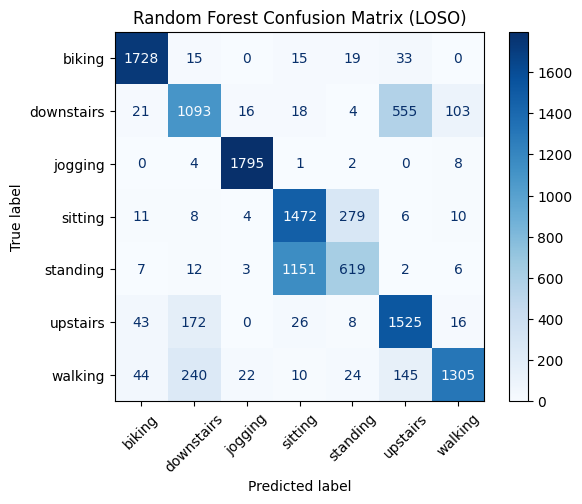

In [32]:
# Plot confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
class_names = sorted(features_df['majority_activity'].unique())  
cm = confusion_matrix(all_y_true, all_y_pred, labels=class_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Random Forest Confusion Matrix (LOSO)")
plt.xticks(rotation=45)
plt.show()

### SVM other position

In [33]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Load features for left and right pockets
features_left = pd.read_csv('Data/features_left_pocket.csv')
features_right = pd.read_csv('Data/features_right_pocket.csv')

participants = features_left['participant'].unique()

svm_params = {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}

results = []
all_y_true = []
all_y_pred = []

for pid in participants:
    train_df = features_left[features_left['participant'] == pid]
    test_df = features_right[features_right['participant'] == pid]
    
    if train_df.empty or test_df.empty:
        print(f"Skipping participant {pid}: insufficient data for Left_pocket or Right_pocket.")
        continue
    
    X_train = train_df.drop(['majority_activity', 'participant', 'position'], axis=1)
    y_train = train_df['majority_activity']
    X_test = test_df.drop(['majority_activity', 'participant', 'position'], axis=1)
    y_test = test_df['majority_activity']
    
    clf = SVC(**svm_params, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    results.append({'participant': pid, 'accuracy': acc, 'report': report})
    
    print(f"Participant {pid} - Accuracy: {acc:.3f}")

mean_acc = np.mean([r['accuracy'] for r in results])
print(f"\nMean LOSO SVM Accuracy (Left→Right): {mean_acc:.3f}")
print(classification_report(y_test,y_pred))


Participant 1 - Accuracy: 0.729
Participant 10 - Accuracy: 0.665
Participant 2 - Accuracy: 0.945
Participant 3 - Accuracy: 0.780
Participant 4 - Accuracy: 0.680
Participant 5 - Accuracy: 0.743
Participant 6 - Accuracy: 0.974
Participant 7 - Accuracy: 0.517
Participant 8 - Accuracy: 0.805
Participant 9 - Accuracy: 0.766

Mean LOSO SVM Accuracy (Left→Right): 0.760
              precision    recall  f1-score   support

      biking       0.87      0.55      0.67       181
  downstairs       0.96      0.90      0.93       181
     jogging       0.99      1.00      1.00       181
     sitting       0.50      0.01      0.01       179
    standing       0.49      1.00      0.66       180
    upstairs       0.69      0.97      0.80       179
     walking       0.96      0.94      0.95       179

    accuracy                           0.77      1260
   macro avg       0.78      0.77      0.72      1260
weighted avg       0.78      0.77      0.72      1260



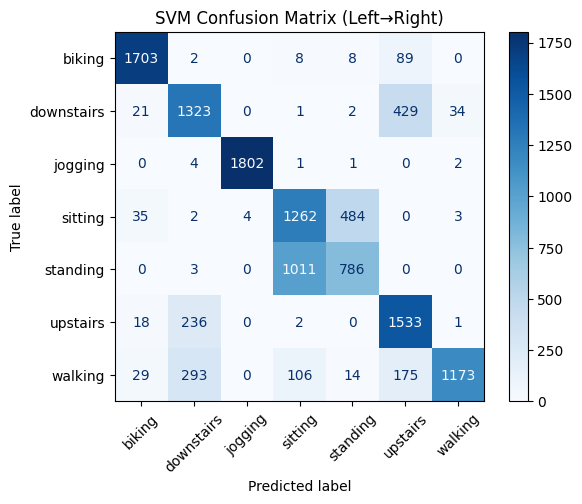

In [34]:
# Plot confusion matrix
import matplotlib.pyplot as plt
class_names = sorted(list(set(all_y_true) | set(all_y_pred)))
cm = confusion_matrix(all_y_true, all_y_pred, labels=class_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("SVM Confusion Matrix (Left→Right)")
plt.xticks(rotation=45)
plt.show()

### Wrist position with svm
train on left pocket and test on wrist

In [30]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Load features for left and right pockets
features_left = pd.read_csv('Data/features_left_pocket.csv')
features_wrist = pd.read_csv('Data/features_wrist.csv')

participants = features_left['participant'].unique()

svm_params = {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}

results = []
all_y_true = []
all_y_pred = []

for pid in participants:
    train_df = features_left[features_left['participant'] == pid]
    test_df = features_wrist[features_wrist['participant'] == pid]
    
    if train_df.empty or test_df.empty:
        print(f"Skipping participant {pid}: insufficient data for Left_pocket or Wrist.")
        continue
    
    X_train = train_df.drop(['majority_activity', 'participant', 'position'], axis=1)
    y_train = train_df['majority_activity']
    X_test = test_df.drop(['majority_activity', 'participant', 'position'], axis=1)
    y_test = test_df['majority_activity']
    
    clf = SVC(**svm_params, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    results.append({'participant': pid, 'accuracy': acc, 'report': report})
    
    print(f"Participant {pid} - Accuracy: {acc:.3f}")

mean_acc = np.mean([r['accuracy'] for r in results])
print(f"\nMean LOSO SVM Accuracy (Left→Wrist): {mean_acc:.3f}")
print(classification_report(y_test,y_pred))


Participant 1 - Accuracy: 0.483
Participant 10 - Accuracy: 0.410
Participant 2 - Accuracy: 0.338
Participant 3 - Accuracy: 0.287
Participant 4 - Accuracy: 0.569
Participant 5 - Accuracy: 0.447
Participant 6 - Accuracy: 0.632
Participant 7 - Accuracy: 0.348
Participant 8 - Accuracy: 0.650
Participant 9 - Accuracy: 0.606

Mean LOSO SVM Accuracy (Left→Wrist): 0.477
              precision    recall  f1-score   support

      biking       0.90      0.29      0.44       181
  downstairs       0.83      1.00      0.91       181
     jogging       0.98      1.00      0.99       181
     sitting       0.46      0.03      0.06       179
    standing       0.40      0.93      0.56       180
    upstairs       0.48      0.98      0.64       179
     walking       0.00      0.00      0.00       179

    accuracy                           0.61      1260
   macro avg       0.58      0.61      0.51      1260
weighted avg       0.58      0.61      0.52      1260



c:\Users\garog\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\garog\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\garog\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

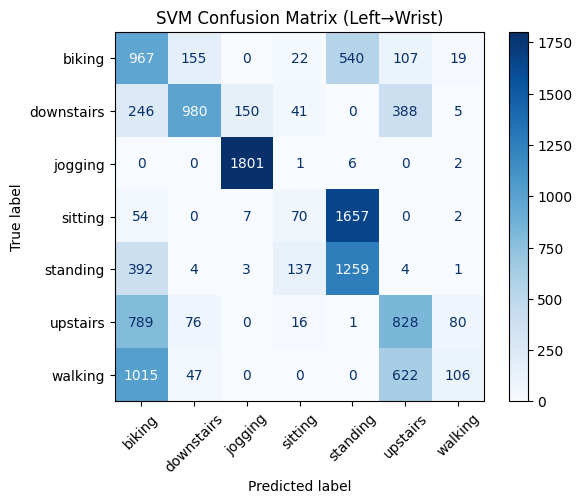

In [31]:
# Plot confusion matrix
import matplotlib.pyplot as plt
class_names = sorted(list(set(all_y_true) | set(all_y_pred)))
cm = confusion_matrix(all_y_true, all_y_pred, labels=class_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("SVM Confusion Matrix (Left→Wrist)")
plt.xticks(rotation=45)
plt.show()

### MLP left pocket train -> Test on Right Pocket

In [35]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

# Load features for left and right pockets
features_left = pd.read_csv('Data/features_left_pocket.csv')
features_right = pd.read_csv('Data/features_right_pocket.csv')

participants = features_left['participant'].unique()

# Define MLP with two hidden layers (e.g., 20 and 10 neurons) and SGD optimizer
mlp = MLPClassifier(hidden_layer_sizes=(20, 20), solver='sgd', activation='tanh',
                        alpha=0.001, momentum=0.95,  max_iter=1000, random_state=42) #max_iter=1000 , early_stopping=True, validation_fraction=0.1

results = []
all_y_true = []
all_y_pred = []

for pid in participants:
    train_df = features_left[features_left['participant'] == pid]
    test_df = features_right[features_right['participant'] == pid]
    
    X_train = train_df.drop(['majority_activity', 'participant', 'position'], axis=1)
    y_train = train_df['majority_activity']
    X_test = test_df.drop(['majority_activity', 'participant', 'position'], axis=1)
    y_test = test_df['majority_activity']
    
    # Normalize features (important for neural networks)
    #scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    clf = mlp
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    results.append({'participant': pid, 'accuracy': acc, 'report': report})
    
    print(f"Participant {pid} - Accuracy: {acc:.3f}")

mean_acc = np.mean([r['accuracy'] for r in results])
print(f"\nMean LOSO MLP Accuracy (Left→Right): {mean_acc:.3f}")
print(classification_report(all_y_true, all_y_pred, zero_division=0))


Participant 1 - Accuracy: 0.721
Participant 10 - Accuracy: 0.686
Participant 2 - Accuracy: 0.837
Participant 3 - Accuracy: 0.739
Participant 4 - Accuracy: 0.675
Participant 5 - Accuracy: 0.728
Participant 6 - Accuracy: 0.934
Participant 7 - Accuracy: 0.507
Participant 8 - Accuracy: 0.887
Participant 9 - Accuracy: 0.713

Mean LOSO MLP Accuracy (Left→Right): 0.743
              precision    recall  f1-score   support

      biking       0.84      0.89      0.86      1810
  downstairs       0.69      0.72      0.71      1810
     jogging       1.00      0.98      0.99      1810
     sitting       0.53      0.68      0.59      1790
    standing       0.61      0.46      0.52      1800
    upstairs       0.67      0.77      0.72      1790
     walking       0.95      0.70      0.80      1790

    accuracy                           0.74     12600
   macro avg       0.76      0.74      0.74     12600
weighted avg       0.76      0.74      0.74     12600

